<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Autoencoder From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
Writing the whole autoencoder in numpy, no framework. 64 pixels go down to a 16 number code and come back to 64. Forward pass, MSE loss and the backprop are all by hand so its clear what is actually being learnt.
</div>

## the network

```
input 64  ->  hidden 16 (sigmoid)  ->  output 64 (sigmoid)
   encoder W1,b1          decoder W2,b2
```

output uses sigmoid because the pixels are scaled to 0 and 1, so the output should also stay in that range. loss is mean squared error between the output and the input itself.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data / 16.0
y = digits.target
print("data :", X.shape)

data : (1797, 64)


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def init_params(n_in, n_code, seed=0):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 0.1, (n_in, n_code))
    b1 = np.zeros(n_code)
    W2 = rng.normal(0, 0.1, (n_code, n_in))
    b2 = np.zeros(n_in)
    return W1, b1, W2, b2

## forward pass
encoder and decoder kept as two seperate functions so the code can be taken out on its own later.

In [4]:
def encode(X, W1, b1):
    return sigmoid(X @ W1 + b1)

def decode(H, W2, b2):
    return sigmoid(H @ W2 + b2)

def forward(X, W1, b1, W2, b2):
    H = encode(X, W1, b1)
    out = decode(H, W2, b2)
    return H, out

## backprop by hand

loss is `mean((out - X)^2)`. sigmoid derivative is `s(1-s)` so:

- error at output : `(out - X) * out * (1 - out)`
- that goes back through W2 to the hidden layer, multiplied again by `h * (1 - h)`

then each gradient is just the input of that layer transposed times its error.

In [18]:
def backward(X, H, out, W2):
    n = len(X)
    d_out = (out - X) * out * (1 - out) / n     # error at the output layer
    gW2 = H.T @ d_out
    gb2 = d_out.sum(axis=0)

    d_hid = (d_out @ W2.T) * H * (1 - H)        # pushed back into the hidden layer
    gW1 = X.T @ d_hid
    gb1 = d_hid.sum(axis=0)
    return gW1, gb1, gW2, gb2

In [6]:
def train(X, n_code=16, epochs=5000, lr=1.0, seed=0):
    W1, b1, W2, b2 = init_params(X.shape[1], n_code, seed)
    history = []

    for ep in range(epochs + 1):
        H, out = forward(X, W1, b1, W2, b2)
        loss = ((out - X) ** 2).mean()
        history.append(loss)

        gW1, gb1, gW2, gb2 = backward(X, H, out, W2)
        W1 -= lr * gW1
        b1 -= lr * gb1
        W2 -= lr * gW2
        b2 -= lr * gb2

        if ep % 1000 == 0:
            print("epoch", str(ep).rjust(4), " loss", round(loss, 5))

    return (W1, b1, W2, b2), history

In [7]:
params, hist = train(X, n_code=16)
W1, b1, W2, b2 = params

epoch    0  loss 0.18253


epoch 1000  loss 0.01732


epoch 2000  loss 0.0123


epoch 3000  loss 0.01067


epoch 4000  loss 0.00993


epoch 5000  loss 0.00948


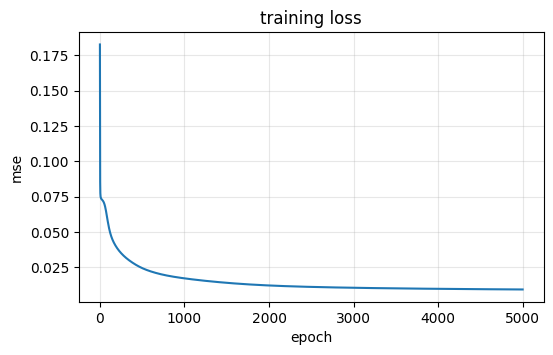

In [9]:
plt.figure(figsize=(6,3.5))
plt.plot(hist)
plt.xlabel('epoch'); plt.ylabel('mse')
plt.title('training loss')
plt.grid(alpha=.3)
plt.show()

## what it rebuilds

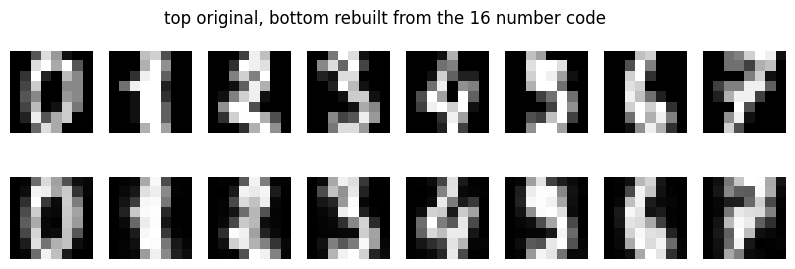

In [11]:
_, out = forward(X, W1, b1, W2, b2)

fig, ax = plt.subplots(2, 8, figsize=(10,3))
for i in range(8):
    ax[0,i].imshow(X[i].reshape(8,8), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(out[i].reshape(8,8), cmap='gray'); ax[1,i].axis('off')
plt.suptitle('top original, bottom rebuilt from the 16 number code')
plt.show()

In [12]:
print("final mse :", round(hist[-1], 5))

final mse : 0.00948


## compare with PCA
same bottleneck size, so its a fair comparison with the linear version from notebook 01.

In [13]:
from sklearn.decomposition import PCA

p = PCA(n_components=16)
pca_rebuilt = p.inverse_transform(p.fit_transform(X))
pca_mse = ((X - pca_rebuilt) ** 2).mean()

print("PCA (linear)        mse :", round(pca_mse, 5))
print("my autoencoder      mse :", round(hist[-1], 5))

PCA (linear)        mse : 0.01104
my autoencoder      mse : 0.00948


## the code layer

each of the 16 hidden units is looking at one pattern in the image. plotting the weights of the encoder shows what each unit responds to.

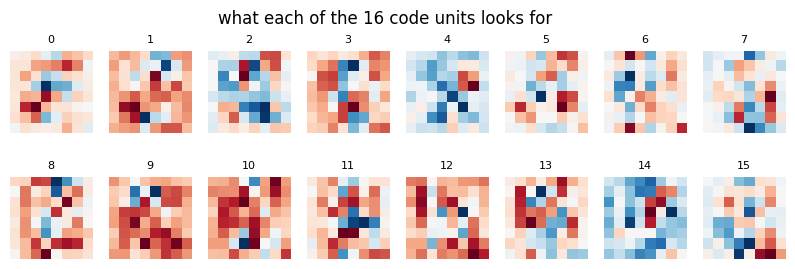

In [15]:
fig, ax = plt.subplots(2, 8, figsize=(10,3))
for i in range(16):
    a = ax[i//8, i%8]
    a.imshow(W1[:, i].reshape(8,8), cmap='RdBu')
    a.set_title(i, fontsize=8); a.axis('off')
plt.suptitle('what each of the 16 code units looks for')
plt.show()

## bottleneck of 2, just to see it

epoch    0  loss 0.17854


epoch 1000  loss 0.05515


epoch 2000  loss 0.0527


epoch 3000  loss 0.0531


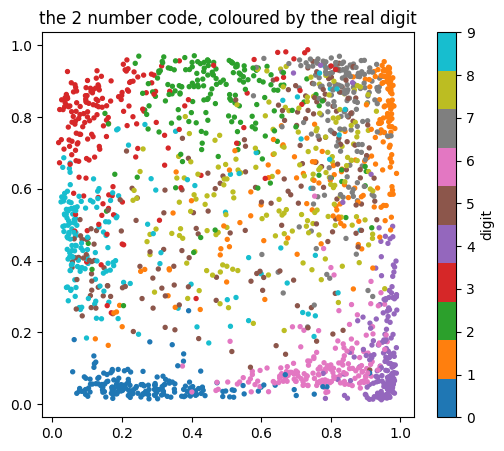

In [16]:
small, hist2 = train(X, n_code=2, epochs=3000)
Ws1, bs1, Ws2, bs2 = small
code2 = encode(X, Ws1, bs1)

plt.figure(figsize=(6,5))
sc = plt.scatter(code2[:,0], code2[:,1], c=y, cmap='tab10', s=8)
plt.colorbar(sc, label='digit')
plt.title('the 2 number code, coloured by the real digit')
plt.show()

the network was never told the labels, still same digits are sitting together. that means the code has learnt something about the shape.

### what i learned
the whole autoencoder is just two matrix multiplies and a loss that compares the output with the input, the hard part is only getting the backprop right.

it ended at 0.0095 mse against PCA 0.0110 with the same 16 size code, so the non linear version is doing better. makes sense, PCA can only fit a straight line through the data while the sigmoid lets this one bend. the loss was still falling at epoch 5000 so it can go lower if trained more.